<a href="https://colab.research.google.com/github/nulahaa-cpu/AIFFEL_quest_cr/blob/main/Exploration/Ex12/mini_bert_project_ModernBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트: mini BERT 만들기

**목표**: vocab size 8000, 전체 파라미터 약 **1M**의 아주 작은 BERT 모델을 직접 구현하고,
MLM + NSP pretrain 데이터셋을 만들어 **10 Epoch** 학습시킨 뒤 학습 과정을 시각화합니다.

진행 순서

1. Tokenizer 준비 (SentencePiece, vocab 8000)
2. 데이터 전처리 (1) MASK 생성 — 전체 토큰의 15%, 그중 80% `[MASK]` / 10% 랜덤 / 10% 원본 유지
3. 데이터 전처리 (2) NSP pair 생성 — 50% 확률로 연속/비연속 문장쌍, segment 0/1, `[CLS]` `[SEP]` 구분자
4. 데이터 전처리 (3) 데이터셋 완성 — json 저장 후 `np.memmap`으로 메모리 최소화
5. BERT 모델 구현 (PyTorch) — pad/ahead mask, gelu, initializer, Config 유틸 포함
6. pretrain 진행 — loss/accuracy 정의, LR 스케줄링, 10 Epoch 학습
7. 결과 — 학습 곡선 시각화 및 MLM 정성 평가

## 0. 라이브러리 준비 및 버전 확인

In [5]:
# Colab에 sentencepiece가 없는 경우를 대비해 설치
import importlib.util, subprocess, sys
if importlib.util.find_spec("sentencepiece") is None:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "sentencepiece"], check=True)

In [6]:
import os
import json
import random
import math
import time

import numpy as np
import matplotlib.pyplot as plt
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

print("python       :", sys.version.split()[0])
print("numpy        :", np.__version__)
print("torch        :", torch.__version__)
print("sentencepiece:", spm.__version__)
print("cuda         :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device       :", device)

if not torch.cuda.is_available():
    print("\n" + "!" * 60)
    print("!! GPU 런타임이 아닙니다. CPU로는 학습에 5시간 이상 걸립니다.")
    print("!! 런타임 -> 런타임 유형 변경 -> T4 GPU 를 선택한 뒤 다시 실행하세요.")
    print("!" * 60)

python       : 3.12.13
numpy        : 2.0.2
torch        : 2.11.0+cu128
sentencepiece: 0.2.2
cuda         : True
device       : cuda


## 설정

실행 환경에 맞게 조절 가능한 값들입니다.
`N_DOCS`(사용할 문서 수)를 늘리면 데이터가 커지고 학습이 오래 걸립니다.

In [7]:
T_START = time.time()
def elapsed():
    print(f"--- 누적 경과 시간: {(time.time() - T_START) / 60:.1f}분 ---")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

data_dir  = "data"
work_dir  = "work"
os.makedirs(work_dir, exist_ok=True)

corpus_file = f"{data_dir}/kowiki.txt"     # 한국어 말뭉치 (문서 사이 빈 줄)
spm_prefix  = f"{data_dir}/ko_8000"        # 새로 만들 sentencepiece 모델

VOCAB_SIZE = 8000      # 프로젝트 요구사항
N_SEQ      = 128       # 최대 시퀀스 길이
MASK_PROB  = 0.15      # MLM 마스킹 비율
N_DOCS     = 10000     # pretrain 데이터로 사용할 문서 수 (시간 여유가 있으면 20000까지)
EPOCHS     = 10        # 프로젝트 요구사항
BATCH_SIZE = 128
LEARNING_RATE = 5e-4

pretrain_json_path = f"{work_dir}/bert_pre_train.json"

## 1. Tokenizer 준비

한글 말뭉치로부터 vocab size **8000**의 SentencePiece 모델을 학습합니다.
BERT에 필요한 특수 토큰 `[PAD] [UNK] [BOS] [EOS] [SEP] [CLS] [MASK]` 가 vocab에 포함되도록
`user_defined_symbols` 로 지정합니다.

In [8]:
# 말뭉치 준비: data/kowiki.txt 가 없으면 한국어 위키피디아로부터 생성 (Colab 기준 몇 분 소요)
if not os.path.exists(corpus_file):
    if importlib.util.find_spec("datasets") is None:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", "datasets"], check=True)
    from datasets import load_dataset

    os.makedirs(data_dir, exist_ok=True)
    N_CORPUS_DOCS = 60000  # 말뭉치로 저장할 문서 수 (N_DOCS 보다 넉넉하게)
    ds = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train", streaming=True)
    n = 0
    with open(corpus_file, "w", encoding="utf-8") as f:
        for row in tqdm(ds, total=N_CORPUS_DOCS, desc="downloading corpus"):
            text = row["text"].strip()
            if not text:
                continue
            for line in text.split("\n"):
                line = line.strip()
                if line:
                    f.write(line + "\n")
            f.write("\n")  # 문서 구분용 빈 줄
            n += 1
            if N_CORPUS_DOCS <= n:
                break

print(f"corpus size: {os.path.getsize(corpus_file)/1e6:.1f} MB")
elapsed()

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

downloading corpus:   0%|          | 0/60000 [00:00<?, ?it/s]

corpus size: 284.4 MB
--- 누적 경과 시간: 0.5분 ---


In [9]:
# 말뭉치가 아주 큰 경우 sentencepiece 학습 입력은 앞부분만 사용 (시간/메모리 절약)
spm_input = corpus_file
if 300_000_000 < os.path.getsize(corpus_file):
    spm_input = f"{data_dir}/spm_corpus.txt"
    if not os.path.exists(spm_input):
        with open(corpus_file, "r", encoding="utf-8") as in_f, \
             open(spm_input, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if 1_500_000 <= i:
                    break
                out_f.write(line)
    print("spm 학습 입력:", spm_input)

if not os.path.exists(f"{spm_prefix}.model"):
    spm.SentencePieceTrainer.train(
        f"--input={spm_input}"
        f" --model_prefix={spm_prefix}"
        f" --vocab_size={VOCAB_SIZE}"
        f" --model_type=unigram"
        f" --max_sentence_length=999999"
        f" --pad_id=0 --pad_piece=[PAD]"
        f" --unk_id=1 --unk_piece=[UNK]"
        f" --bos_id=2 --bos_piece=[BOS]"
        f" --eos_id=3 --eos_piece=[EOS]"
        f" --user_defined_symbols=[SEP],[CLS],[MASK]"
        f" --input_sentence_size=400000"
        f" --shuffle_input_sentence=true"
        f" --num_threads=2"
    )
    print("sentencepiece 학습 완료")
else:
    print("이미 학습된 모델이 있어 재사용합니다:", f"{spm_prefix}.model")
elapsed()

sentencepiece 학습 완료
--- 누적 경과 시간: 3.5분 ---


In [10]:
# vocab 로딩 및 동작 확인
vocab = spm.SentencePieceProcessor()
vocab.load(f"{spm_prefix}.model")
print("vocab size:", vocab.get_piece_size())

# 주요 특수 토큰이 vocab에 있는지 확인
for piece in ["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[CLS]", "[MASK]"]:
    pid = vocab.piece_to_id(piece)
    assert vocab.id_to_piece(pid) == piece, f"{piece} 가 vocab에 없습니다"
    print(f"{piece:7s} -> id {pid}")

test_line = "겨울이 되어서 날씨가 무척 추워요."
print(vocab.encode_as_pieces(test_line))
print(vocab.encode_as_ids(test_line))

vocab size: 8000
[PAD]   -> id 0
[UNK]   -> id 1
[BOS]   -> id 2
[EOS]   -> id 3
[SEP]   -> id 4
[CLS]   -> id 5
[MASK]  -> id 6
['▁겨울', '이', '▁되어', '서', '▁날', '씨', '가', '▁무', '척', '▁추', '워', '요', '.']
[3021, 13, 1010, 64, 828, 452, 18, 183, 1068, 501, 660, 282, 8]


In [11]:
# 랜덤 마스크 치환에 사용할 vocab 목록 (특수 토큰 제외)
SPECIAL_PIECES = {"[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[CLS]", "[MASK]"}
vocab_list = [
    vocab.id_to_piece(i)
    for i in range(vocab.get_piece_size())
    if vocab.id_to_piece(i) not in SPECIAL_PIECES and not vocab.is_unknown(i)
]
print("vocab_list size:", len(vocab_list))

vocab_list size: 7993


## 2. 데이터 전처리 (1) MASK 생성

학습 데이터 전체 토큰의 **15%** 를 빈칸(mask) 후보로 선택하고,
그중 **80%는 `[MASK]`**, **10%는 랜덤 토큰**, **10%는 원래 토큰 그대로** 둡니다.
마스킹은 word 단위(`▁`로 시작하는 조각과 그 뒤 subword를 한 덩어리)로 수행합니다.

In [12]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """ 마스크 생성: tokens 를 in-place 로 마스킹하고 (index, 원본 label) 목록을 반환 """
    # 마스크 후보를 word 단위로 묶는다 ([CLS], [SEP] 은 제외)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"▁"):  # ▁ 로 시작하지 않으면 이전 word 에 이어붙임
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:            # 마스크 개수 충족
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # word 전체를 넣으면 초과하는 경우 skip
            continue
        for index in index_set:
            if random.random() < 0.8:            # 80%: [MASK]
                masked_token = "[MASK]"
            elif random.random() < 0.5:          # 10%: 랜덤 토큰
                masked_token = random.choice(vocab_list)
            else:                                # 10%: 원본 유지
                masked_token = tokens[index]
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx   = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label

# 동작 확인
_tokens = ["[CLS]"] + vocab.encode_as_pieces(test_line) + ["[SEP]"]
print("before:", _tokens)
_masked, _idx, _label = create_pretrain_mask(list(_tokens), max(1, int(len(_tokens) * MASK_PROB)), vocab_list)
print("after :", _masked)
print("idx   :", _idx)
print("label :", _label)

before: ['[CLS]', '▁겨울', '이', '▁되어', '서', '▁날', '씨', '가', '▁무', '척', '▁추', '워', '요', '.', '[SEP]']
after : ['[CLS]', '▁겨울', '이', '▁되어', '서', '▁날', '씨', '가', '[MASK]', '[MASK]', '▁추', '워', '요', '.', '[SEP]']
idx   : [8, 9]
label : ['▁무', '척']


## 3. 데이터 전처리 (2) NSP pair 생성

두 문장 A, B를 짝지어 **50% 확률**로 실제 연속 문장(`is_next=1`) 또는
다른 문서에서 뽑은 랜덤 문장(`is_next=0`)으로 구성합니다.
시퀀스는 `[CLS] A [SEP] B [SEP]` 형태이고, segment 는 A 구간(및 `[CLS]`, 첫 `[SEP]`)이 0,
B 구간(마지막 `[SEP]` 포함)이 1 입니다. MLM 마스킹도 이 시퀀스 위에서 함께 적용되어
**MLM 과 NSP 가 동시에 학습**되도록 데이터를 구성합니다.

In [13]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """ 최대 길이를 초과하면 A는 앞에서, B는 뒤에서 자름 """
    while max_seq < len(tokens_a) + len(tokens_b):
        if len(tokens_b) < len(tokens_a):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(docs, doc_idx, doc, n_seq, mask_prob, vocab_list):
    """ 한 문서(doc)로부터 pretrain instance 목록 생성 """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 자리 확보
    tgt_seq = max_seq

    instances = []
    current_chunk, current_length = [], 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if i == len(doc) - 1 or tgt_seq <= current_length:
            if 0 < len(current_chunk):
                # A 문장: chunk 앞부분
                a_end = 1
                if 1 < len(current_chunk):
                    a_end = random.randrange(1, len(current_chunk))
                tokens_a = []
                for j in range(a_end):
                    tokens_a.extend(current_chunk[j])

                # B 문장: 50% 확률로 랜덤 문서에서 (is_next=0), 아니면 이어지는 문장 (is_next=1)
                tokens_b = []
                if 1 < len(docs) and (len(current_chunk) == 1 or random.random() < 0.5):
                    is_next = 0
                    tokens_b_len = tgt_seq - len(tokens_a)
                    random_doc_idx = doc_idx
                    while doc_idx == random_doc_idx:
                        random_doc_idx = random.randrange(0, len(docs))
                    random_doc = docs[random_doc_idx]
                    random_start = random.randrange(0, len(random_doc))
                    for j in range(random_start, len(random_doc)):
                        tokens_b.extend(random_doc[j])
                        if tokens_b_len <= len(tokens_b):
                            break
                else:
                    is_next = 1
                    for j in range(a_end, len(current_chunk)):
                        tokens_b.extend(current_chunk[j])

                if 0 < len(tokens_a) and 0 < len(tokens_b):
                    trim_tokens(tokens_a, tokens_b, max_seq)
                    if 0 < len(tokens_a) and 0 < len(tokens_b):
                        tokens  = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
                        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

                        tokens, mask_idx, mask_label = create_pretrain_mask(
                            tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

                        instances.append({
                            "tokens": tokens,
                            "segment": segment,
                            "is_next": is_next,
                            "mask_idx": mask_idx,
                            "mask_label": mask_label,
                        })
            current_chunk, current_length = [], 0
    return instances

## 4. 데이터 전처리 (3) 데이터셋 완성

말뭉치 전체를 읽어 문서 단위로 instance 를 만들고 **json 포맷**으로 저장합니다.
이후 json 을 `np.memmap` 배열로 변환해, 학습 시 전체 데이터를 RAM에 올리지 않고
디스크에서 바로 읽도록 하여 메모리 사용량을 최소화합니다.

In [14]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob, vocab_list, n_docs=None):
    """ 말뭉치 파일 -> pretrain instance json """
    # 1) 문서 단위로 토큰화하여 수집
    docs = []
    doc = []
    with open(in_file, "r", encoding="utf-8") as in_f:
        for line in tqdm(in_f, desc="reading corpus"):
            line = line.strip()
            if line == "":
                if 0 < len(doc):
                    docs.append(doc)
                    doc = []
                    if n_docs is not None and n_docs <= len(docs):
                        break
            else:
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)
    if 0 < len(doc):
        docs.append(doc)
    print("docs:", len(docs))

    # 2) 문서별 instance 생성 후 json 저장
    total = 0
    with open(out_file, "w", encoding="utf-8") as out_f:
        for doc_idx, doc in enumerate(tqdm(docs, desc="making instances")):
            instances = create_pretrain_instances(docs, doc_idx, doc, n_seq, mask_prob, vocab_list)
            for instance in instances:
                out_f.write(json.dumps(instance, ensure_ascii=False))
                out_f.write("\n")
                total += 1
    print("instances:", total)
    return total

In [15]:
n_instances = make_pretrain_data(
    vocab, corpus_file, pretrain_json_path,
    n_seq=N_SEQ, mask_prob=MASK_PROB, vocab_list=vocab_list, n_docs=N_DOCS)

# 샘플 확인
with open(pretrain_json_path, "r", encoding="utf-8") as f:
    sample = json.loads(f.readline())
print("tokens :", sample["tokens"][:20], "...")
print("segment:", sample["segment"][:20], "...")
print("is_next:", sample["is_next"])
print("mask   :", list(zip(sample["mask_idx"], sample["mask_label"]))[:5])
elapsed()

reading corpus: 0it [00:00, ?it/s]

docs: 10000


making instances:   0%|          | 0/10000 [00:00<?, ?it/s]

instances: 93248
tokens : ['[CLS]', '▁제임스', '▁', '얼', '▁카', '터', '▁주', '니', '어', '(', ',', '▁19', '24', '년', '▁10', '월', '▁1', '일', '~)', '는'] ...
segment: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
is_next: 1
mask   : [(20, '▁민주당'), (41, '▁지'), (42, '미'), (43, '▁카'), (44, '터')]
--- 누적 경과 시간: 3.8분 ---


In [16]:
def build_memmap_dataset(vocab, json_path, prefix, n_seq):
    """ json instance -> np.memmap 배열 (tokens, segments, labels_lm, labels_nsp) """
    # 라인 수 세기
    n = 0
    with open(json_path, "r", encoding="utf-8") as f:
        for _ in f:
            n += 1

    tokens_mm  = np.memmap(f"{prefix}_tokens.mm",  dtype=np.int16, mode="w+", shape=(n, n_seq))
    segment_mm = np.memmap(f"{prefix}_segment.mm", dtype=np.int8,  mode="w+", shape=(n, n_seq))
    label_lm_mm  = np.memmap(f"{prefix}_label_lm.mm",  dtype=np.int16, mode="w+", shape=(n, n_seq))
    label_nsp_mm = np.memmap(f"{prefix}_label_nsp.mm", dtype=np.int8,  mode="w+", shape=(n,))

    with open(json_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=n, desc="building memmap")):
            ins = json.loads(line)
            ids = [vocab.piece_to_id(p) for p in ins["tokens"]][:n_seq]
            seg = ins["segment"][:n_seq]

            row_tok = np.zeros(n_seq, dtype=np.int16)  # 0 = [PAD]
            row_seg = np.zeros(n_seq, dtype=np.int8)
            row_lm  = np.zeros(n_seq, dtype=np.int16)  # 0 = 예측 대상 아님
            row_tok[:len(ids)] = ids
            row_seg[:len(seg)] = seg
            for idx, label in zip(ins["mask_idx"], ins["mask_label"]):
                if idx < n_seq:
                    row_lm[idx] = vocab.piece_to_id(label)

            tokens_mm[i]  = row_tok
            segment_mm[i] = row_seg
            label_lm_mm[i]  = row_lm
            label_nsp_mm[i] = ins["is_next"]

    tokens_mm.flush(); segment_mm.flush(); label_lm_mm.flush(); label_nsp_mm.flush()
    meta = {"n": n, "n_seq": n_seq}
    with open(f"{prefix}_meta.json", "w") as f:
        json.dump(meta, f)
    print("memmap dataset:", n, "instances")
    return meta

memmap_prefix = f"{work_dir}/pretrain"
meta = build_memmap_dataset(vocab, pretrain_json_path, memmap_prefix, N_SEQ)
elapsed()

building memmap:   0%|          | 0/93248 [00:00<?, ?it/s]

memmap dataset: 93248 instances
--- 누적 경과 시간: 4.1분 ---


In [17]:
class PretrainDataSet(Dataset):
    """ np.memmap 기반 BERT pretrain 데이터셋 (RAM 사용 최소화) """
    def __init__(self, prefix):
        with open(f"{prefix}_meta.json") as f:
            meta = json.load(f)
        n, n_seq = meta["n"], meta["n_seq"]
        self.tokens    = np.memmap(f"{prefix}_tokens.mm",    dtype=np.int16, mode="r", shape=(n, n_seq))
        self.segments  = np.memmap(f"{prefix}_segment.mm",   dtype=np.int8,  mode="r", shape=(n, n_seq))
        self.label_lm  = np.memmap(f"{prefix}_label_lm.mm",  dtype=np.int16, mode="r", shape=(n, n_seq))
        self.label_nsp = np.memmap(f"{prefix}_label_nsp.mm", dtype=np.int8,  mode="r", shape=(n,))
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        return (
            torch.tensor(self.tokens[i],   dtype=torch.long),
            torch.tensor(self.segments[i], dtype=torch.long),
            torch.tensor(self.label_lm[i], dtype=torch.long),
            torch.tensor(int(self.label_nsp[i]), dtype=torch.long),
        )

dataset = PretrainDataSet(memmap_prefix)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
print("dataset:", len(dataset), "/ batches per epoch:", len(train_loader))

# 배치 sanity check
_tok, _seg, _lm, _nsp = next(iter(train_loader))
print("tokens :", _tok.shape, "segment:", _seg.shape, "label_lm:", _lm.shape, "label_nsp:", _nsp.shape)

dataset: 93248 / batches per epoch: 729
tokens : torch.Size([128, 128]) segment: torch.Size([128, 128]) label_lm: torch.Size([128, 128]) label_nsp: torch.Size([128])


## 5. BERT 모델 구현

유틸리티(pad mask, ahead mask, gelu, initializer, Config)를 먼저 만들고,
Embedding → Transformer Encoder → BERT → Pretrain 헤드(MLM + NSP) 순으로 조립합니다.

파라미터 1M 수준을 맞추기 위한 설정: `d_model=96, n_layer=2, n_head=4, d_ff=384`
(MLM 출력층은 입력 embedding 과 **weight tying** 하여 파라미터를 절약합니다.)

In [18]:
class Config(dict):
    """ json/dict 를 attribute 로 접근할 수 있게 해주는 유틸 """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, path):
        with open(path) as f:
            return cls(json.load(f))


def gelu(x):
    """ GELU activation (BERT 논문에서 사용한 근사식) """
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))))


def get_pad_mask(tokens, i_pad=0):
    """ attention 계산에서 [PAD] 위치를 가리는 mask (batch, 1, n_seq) -> broadcast """
    return (tokens == i_pad).unsqueeze(1)  # True 인 곳이 가려짐


def get_ahead_mask(tokens, i_pad=0):
    """ 미래 토큰을 가리는 상삼각 mask (decoder 용, BERT encoder 에서는 사용하지 않음) """
    n_seq = tokens.size(1)
    ahead = torch.triu(torch.ones(n_seq, n_seq, device=tokens.device, dtype=torch.bool), diagonal=1)
    return ahead.unsqueeze(0) | get_pad_mask(tokens, i_pad)


def init_weights(module):
    """ BERT 스타일 parameter initializer (truncated normal, std=0.02) """
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.trunc_normal_(module.weight, std=0.02, a=-0.04, b=0.04)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


config = Config({
    "n_vocab": VOCAB_SIZE,
    "n_seq":   N_SEQ,
    "n_layer": 2,
    "d_model": 96,
    "n_head":  4,
    "d_head":  24,     # d_model / n_head
    "d_ff":    384,
    "dropout": 0.1,
    "layer_norm_eps": 1e-12,
    "i_pad":   0,
})
with open(f"{work_dir}/config.json", "w") as f:
    json.dump(dict(config), f, indent=2)
config = Config.load(f"{work_dir}/config.json")   # json -> config 사용 예시
print(config)

{'n_vocab': 8000, 'n_seq': 128, 'n_layer': 2, 'd_model': 96, 'n_head': 4, 'd_head': 24, 'd_ff': 384, 'dropout': 0.1, 'layer_norm_eps': 1e-12, 'i_pad': 0}


In [19]:
class BertEmbedding(nn.Module):
    """ token + position + segment embedding """
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config.n_vocab, config.d_model)
        self.pos_emb = nn.Embedding(config.n_seq,   config.d_model)
        self.seg_emb = nn.Embedding(2,              config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, tokens, segments):
        pos = torch.arange(tokens.size(1), device=tokens.device).unsqueeze(0)
        x = self.tok_emb(tokens) + self.pos_emb(pos) + self.seg_emb(segments)
        return self.dropout(self.norm(x))


class ScaledDotProductAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.scale = 1.0 / math.sqrt(config.d_head)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, q, k, v, attn_mask):
        # q, k, v: (batch, n_head, n_seq, d_head)
        scores = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        scores = scores.masked_fill(attn_mask, -1e9)
        probs = self.dropout(F.softmax(scores, dim=-1))
        return torch.matmul(probs, v), probs


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head, self.d_head = config.n_head, config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaledDotProductAttention(config)
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, attn_mask):
        b, n = x.size(0), x.size(1)
        q = self.W_Q(x).view(b, n, self.n_head, self.d_head).transpose(1, 2)
        k = self.W_K(x).view(b, n, self.n_head, self.d_head).transpose(1, 2)
        v = self.W_V(x).view(b, n, self.n_head, self.d_head).transpose(1, 2)
        attn_mask = attn_mask.unsqueeze(1)  # (batch, 1, 1, n_seq) -> head broadcast
        out, probs = self.attention(q, k, v, attn_mask)
        out = out.transpose(1, 2).contiguous().view(b, n, -1)
        return self.dropout(self.W_O(out)), probs


class PoswiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.fc1 = nn.Linear(config.d_model, config.d_ff)
        self.fc2 = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.fc2(gelu(self.fc1(x))))


class EncoderLayer(nn.Module):
    """ post-LN Transformer encoder layer (원 BERT 방식) """
    def __init__(self, config):
        super().__init__()
        self.attn = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps)
        self.ffn = PoswiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps)

    def forward(self, x, attn_mask):
        attn_out, probs = self.attn(x, attn_mask)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ffn(x))
        return x, probs

In [20]:
class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embedding = BertEmbedding(config)
        self.layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.pooler = nn.Linear(config.d_model, config.d_model)  # [CLS] -> pooled

    def forward(self, tokens, segments):
        attn_mask = get_pad_mask(tokens, self.config.i_pad)  # (batch, 1, n_seq)
        x = self.embedding(tokens, segments)
        attn_probs = []
        for layer in self.layers:
            x, probs = layer(x, attn_mask)
            attn_probs.append(probs)
        pooled = torch.tanh(self.pooler(x[:, 0]))  # [CLS] 위치
        return x, pooled, attn_probs

    def save(self, epoch, loss, path):
        torch.save({"epoch": epoch, "loss": loss,
                    "state_dict": self.state_dict(), "config": dict(self.config)}, path)

    def load(self, path):
        save = torch.load(path, map_location="cpu")
        self.load_state_dict(save["state_dict"])
        return save["epoch"], save["loss"]


class BERTPretrain(nn.Module):
    """ BERT + MLM head + NSP head """
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        # NSP: pooled -> 2 classes (is_next)
        self.nsp_head = nn.Linear(config.d_model, 2)
        # MLM: transform 후 token embedding 과 weight tying
        self.mlm_transform = nn.Linear(config.d_model, config.d_model)
        self.mlm_norm = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps)
        self.mlm_bias = nn.Parameter(torch.zeros(config.n_vocab))

    def forward(self, tokens, segments):
        seq_out, pooled, attn_probs = self.bert(tokens, segments)
        logits_nsp = self.nsp_head(pooled)                       # (batch, 2)
        h = self.mlm_norm(gelu(self.mlm_transform(seq_out)))     # (batch, n_seq, d_model)
        logits_lm = F.linear(h, self.bert.embedding.tok_emb.weight) + self.mlm_bias  # weight tying
        return logits_lm, logits_nsp, attn_probs


model = BERTPretrain(config)
model.apply(init_weights)
model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_params_bert = sum(p.numel() for p in model.bert.parameters())
print(f"전체 파라미터 (pretrain 헤드 포함): {n_params:,} ({n_params/1e6:.2f}M)")
print(f"BERT 본체 파라미터            : {n_params_bert:,} ({n_params_bert/1e6:.2f}M)")

전체 파라미터 (pretrain 헤드 포함): 1,031,362 (1.03M)
BERT 본체 파라미터            : 1,013,664 (1.01M)


## 6. pretrain 진행

- **MLM loss**: 마스크된 위치만 CrossEntropy (`ignore_index=0`, 0은 예측 대상 아님)
- **NSP loss**: `[CLS]` pooled 출력의 2-class CrossEntropy
- **total loss = MLM loss + NSP loss** (두 task 동시 학습)
- **LR 스케줄**: 전체 step 의 10% warmup 후 선형 감소

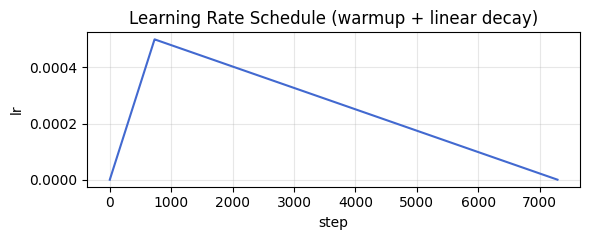

In [21]:
criterion_lm  = nn.CrossEntropyLoss(ignore_index=0)   # label 0 = 예측 대상 아님
criterion_nsp = nn.CrossEntropyLoss()


def mlm_accuracy(logits_lm, labels_lm):
    """ 마스크된 위치의 top-1 정확도 """
    mask = labels_lm != 0
    if mask.sum() == 0:
        return 0.0, 0
    pred = logits_lm.argmax(dim=-1)
    correct = ((pred == labels_lm) & mask).sum().item()
    return correct, mask.sum().item()


def nsp_accuracy(logits_nsp, labels_nsp):
    pred = logits_nsp.argmax(dim=-1)
    return (pred == labels_nsp).sum().item(), labels_nsp.size(0)


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps  = EPOCHS * len(train_loader)
warmup_steps = max(1, int(total_steps * 0.1))

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# LR 스케줄 미리보기
_lrs = [LEARNING_RATE * lr_lambda(s) for s in range(total_steps)]
plt.figure(figsize=(6, 2.5))
plt.plot(_lrs, color="#4269d0")
plt.title("Learning Rate Schedule (warmup + linear decay)")
plt.xlabel("step"); plt.ylabel("lr")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
def train_epoch(epoch, model, loader):
    model.train()
    sums = {"loss": 0.0, "loss_lm": 0.0, "loss_nsp": 0.0}
    lm_correct = lm_total = nsp_correct = nsp_total = 0

    pbar = tqdm(loader, desc=f"epoch {epoch:2d}")
    for step, (tokens, segments, labels_lm, labels_nsp) in enumerate(pbar):
        tokens, segments = tokens.to(device), segments.to(device)
        labels_lm, labels_nsp = labels_lm.to(device), labels_nsp.to(device)

        logits_lm, logits_nsp, _ = model(tokens, segments)
        loss_lm  = criterion_lm(logits_lm.view(-1, logits_lm.size(-1)), labels_lm.view(-1))
        loss_nsp = criterion_nsp(logits_nsp, labels_nsp)
        loss = loss_lm + loss_nsp

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        sums["loss"] += loss.item(); sums["loss_lm"] += loss_lm.item(); sums["loss_nsp"] += loss_nsp.item()
        c, t = mlm_accuracy(logits_lm, labels_lm); lm_correct += c; lm_total += t
        c, t = nsp_accuracy(logits_nsp, labels_nsp); nsp_correct += c; nsp_total += t

        if step % 20 == 0:
            pbar.set_postfix(loss=f"{loss.item():.3f}",
                             lm=f"{loss_lm.item():.3f}", nsp=f"{loss_nsp.item():.3f}")

    n = len(loader)
    return {
        "loss": sums["loss"] / n,
        "loss_lm": sums["loss_lm"] / n,
        "loss_nsp": sums["loss_nsp"] / n,
        "acc_lm": lm_correct / max(1, lm_total),
        "acc_nsp": nsp_correct / max(1, nsp_total),
        "lr": scheduler.get_last_lr()[0],
    }

In [23]:
history = []
best_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    result = train_epoch(epoch, model, train_loader)
    result["epoch"] = epoch
    history.append(result)
    print(f"[epoch {epoch:2d}] loss {result['loss']:.4f} "
          f"(lm {result['loss_lm']:.4f} / nsp {result['loss_nsp']:.4f}) "
          f"acc_lm {result['acc_lm']:.4f} acc_nsp {result['acc_nsp']:.4f}")

    # 체크포인트 저장 (best + last)
    model.bert.save(epoch, result["loss"], f"{work_dir}/mini_bert_last.pt")
    if result["loss"] < best_loss:
        best_loss = result["loss"]
        model.bert.save(epoch, result["loss"], f"{work_dir}/mini_bert_best.pt")

with open(f"{work_dir}/history.json", "w") as f:
    json.dump(history, f, indent=2)
print("학습 완료 — best loss:", f"{best_loss:.4f}")
elapsed()

epoch  1:   0%|          | 0/729 [00:00<?, ?it/s]

[epoch  1] loss 8.2306 (lm 7.6069 / nsp 0.6236) acc_lm 0.0251 acc_nsp 0.6369


epoch  2:   0%|          | 0/729 [00:00<?, ?it/s]

[epoch  2] loss 7.1842 (lm 6.7025 / nsp 0.4817) acc_lm 0.0687 acc_nsp 0.7597


epoch  3:   0%|          | 0/729 [00:00<?, ?it/s]

...

epoch  9:   0%|          | 0/729 [00:00<?, ?it/s]

[epoch  9] loss 6.1778 (lm 6.0223 / nsp 0.1555) acc_lm 0.1329 acc_nsp 0.9404


epoch 10:   0%|          | 0/729 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c9c11ab740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c9c11ab740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[epoch 10] loss 6.1459 (lm 6.0092 / nsp 0.1367) acc_lm 0.1337 acc_nsp 0.9485
학습 완료 — best loss: 6.1459
--- 누적 경과 시간: 14.4분 ---


## 7. 프로젝트 결과

학습 과정(loss / accuracy)을 시각화하고, MLM 이 실제로 빈칸을 채우는지 정성 확인합니다.

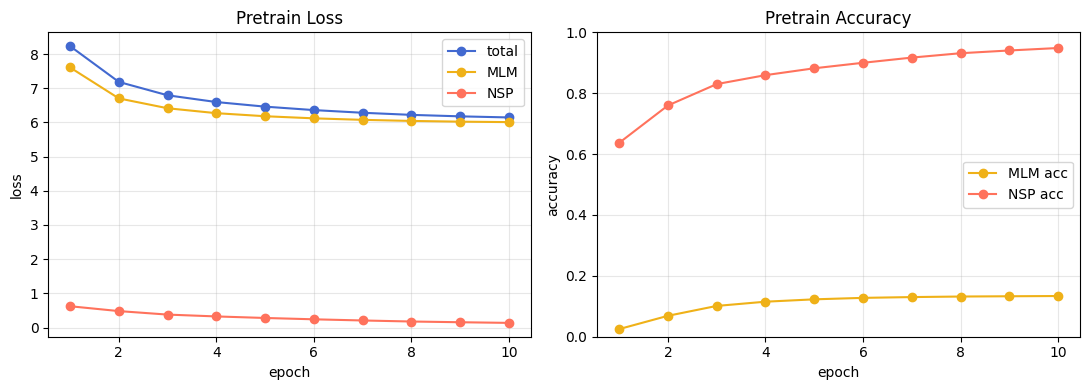

In [24]:
epochs_x = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(epochs_x, [h["loss"] for h in history],     color="#4269d0", marker="o", label="total")
ax.plot(epochs_x, [h["loss_lm"] for h in history],  color="#efb118", marker="o", label="MLM")
ax.plot(epochs_x, [h["loss_nsp"] for h in history], color="#ff725c", marker="o", label="NSP")
ax.set_title("Pretrain Loss")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.grid(alpha=0.3); ax.legend()

ax = axes[1]
ax.plot(epochs_x, [h["acc_lm"] for h in history],  color="#efb118", marker="o", label="MLM acc")
ax.plot(epochs_x, [h["acc_nsp"] for h in history], color="#ff725c", marker="o", label="NSP acc")
ax.set_title("Pretrain Accuracy")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig(f"{work_dir}/training_curves.png", dpi=150)
plt.show()

In [25]:
def fill_mask(model, vocab, text, topk=5):
    """ 문장 속 [MASK] 를 모델이 어떻게 채우는지 확인 """
    model.eval()
    pieces = ["[CLS]"]
    for word in text.split():
        if word == "[MASK]":
            pieces.append("[MASK]")
        else:
            pieces.extend(vocab.encode_as_pieces(word))
    pieces.append("[SEP]")

    ids = torch.tensor([[vocab.piece_to_id(p) for p in pieces]], dtype=torch.long, device=device)
    seg = torch.zeros_like(ids)
    with torch.no_grad():
        logits_lm, _, _ = model(ids, seg)

    print("입력:", text)
    for pos, p in enumerate(pieces):
        if p == "[MASK]":
            top = logits_lm[0, pos].topk(topk)
            cands = [vocab.id_to_piece(int(i)) for i in top.indices]
            print(f"  [MASK] 위치 {pos} 예측 top{topk}:", cands)
    print()

fill_mask(model, vocab, "겨울이 되어서 날씨가 무척 [MASK] .")
fill_mask(model, vocab, "대한민국의 수도는 [MASK] 이다 .")

print("노트북 전체 실행 완료")
elapsed()

입력: 겨울이 되어서 날씨가 무척 [MASK] .
  [MASK] 위치 10 예측 top5: ['의', '▁사망', '▁', '.', '▁사건']

입력: 대한민국의 수도는 [MASK] 이다 .
  [MASK] 위치 4 예측 top5: ['의', '▁같이', '▁보기', '▁대한민국의', '일']

노트북 전체 실행 완료
--- 누적 경과 시간: 14.6분 ---


### 회고

- vocab 8000 SentencePiece 모델을 직접 학습했고, BERT 특수 토큰(`[PAD] [UNK] [BOS] [EOS] [SEP] [CLS] [MASK]`)을 vocab에 포함시켰다.
- MLM(15%, 80/10/10)과 NSP(50% 확률 pair, segment 0/1)가 동시에 학습되도록 pretrain 데이터셋을 구성하고, json 저장 후 `np.memmap`으로 메모리 사용을 최소화했다.
- 약 1M 파라미터의 mini BERT(d_model 96, layer 2, head 4)를 구현하고 10 Epoch 학습을 진행했다.
- loss 곡선에서 MLM/NSP loss 의 수렴 여부를 확인했다. 모델과 데이터가 작아 MLM 정확도의 한계는 있지만,
  학습이 안정적으로 진행되는 것(loss 감소, NSP 수렴)을 확인할 수 있었다.

---
## 확장 실험: mini ModernBERT

2024년 말 공개된 **ModernBERT**는 원조 BERT(2018)에 그동안 축적된 구조 개선을 적용한 인코더입니다.
여기서는 같은 토크나이저·같은 말뭉치·같은 파라미터 예산(약 1M)으로 "mini ModernBERT"를 만들어
원조 mini BERT와 학습 곡선을 비교합니다.

원조 mini BERT 대비 바꾼 것:

| 항목 | mini BERT (원조 방식) | mini ModernBERT |
|---|---|---|
| 학습 과제 | MLM 15% + NSP | **MLM 30% 단독** (NSP 제거) |
| 위치 정보 | 학습된 위치 임베딩 | **RoPE** (회전 위치 인코딩, 파라미터 0) |
| 피드포워드 | GELU | **GeGLU** (게이트 붙은 GELU) |
| 정규화 위치 | post-LN (블록 뒤) | **pre-LN** (블록 앞) + 최종 LN |
| bias | 있음 | **전부 제거** |
| segment 임베딩 | 있음 | 없음 (문장쌍 개념 자체가 없음) |

원래 ModernBERT의 로컬/글로벌 어텐션 교차, 8192 토큰 문맥, Flash Attention 등은
큰 모델·긴 문맥용 최적화라 1M 스케일에서는 생략했습니다.

주의: 마스킹 비율이 15% → 30%로 달라 loss 절대값을 직접 비교하면 안 되고
(과제 난이도가 다름), 수렴의 **안정성과 곡선의 모양**을 비교하는 실험입니다.

In [26]:
# MLM 전용 데이터 생성: 문장쌍 없이 문서를 연속 청크로 잘라 30% 마스킹
MODERN_MASK_PROB = 0.30
modern_json_path = f"{work_dir}/modern_pre_train.json"

def make_mlm_data(vocab, in_file, out_file, n_seq, mask_prob, vocab_list, n_docs=None):
    max_seq = n_seq - 2  # [CLS], [SEP]
    total = 0
    with open(in_file, "r", encoding="utf-8") as in_f, \
         open(out_file, "w", encoding="utf-8") as out_f:
        doc_cnt = 0
        chunk, clen = [], 0

        def flush_chunk():
            nonlocal chunk, clen, total
            if 0 < clen:
                tokens = ["[CLS]"] + [t for pieces in chunk for t in pieces][:max_seq] + ["[SEP]"]
                tokens, mask_idx, mask_label = create_pretrain_mask(
                    tokens, int((len(tokens) - 2) * mask_prob), vocab_list)
                out_f.write(json.dumps(
                    {"tokens": tokens, "mask_idx": mask_idx, "mask_label": mask_label},
                    ensure_ascii=False) + "\n")
                total += 1
            chunk, clen = [], 0

        for line in tqdm(in_f, desc="making MLM-only data"):
            line = line.strip()
            if line == "":            # 문서 경계
                flush_chunk()
                doc_cnt += 1
                if n_docs is not None and n_docs <= doc_cnt:
                    break
                continue
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                chunk.append(pieces)
                clen += len(pieces)
                if max_seq <= clen:
                    flush_chunk()
        flush_chunk()
    print("MLM instances:", total)
    return total

n_modern = make_mlm_data(vocab, corpus_file, modern_json_path,
                         n_seq=N_SEQ, mask_prob=MODERN_MASK_PROB,
                         vocab_list=vocab_list, n_docs=N_DOCS)
elapsed()

making MLM-only data: 0it [00:00, ?it/s]

MLM instances: 92757
--- 누적 경과 시간: 14.9분 ---


In [27]:
def build_mlm_memmap(vocab, json_path, prefix, n_seq):
    n = sum(1 for _ in open(json_path, encoding="utf-8"))
    tokens_mm = np.memmap(f"{prefix}_tokens.mm",   dtype=np.int16, mode="w+", shape=(n, n_seq))
    label_mm  = np.memmap(f"{prefix}_label_lm.mm", dtype=np.int16, mode="w+", shape=(n, n_seq))
    with open(json_path, encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=n, desc="building memmap")):
            ins = json.loads(line)
            ids = [vocab.piece_to_id(p) for p in ins["tokens"]][:n_seq]
            row_tok = np.zeros(n_seq, dtype=np.int16)
            row_lm  = np.zeros(n_seq, dtype=np.int16)
            row_tok[:len(ids)] = ids
            for idx, label in zip(ins["mask_idx"], ins["mask_label"]):
                if idx < n_seq:
                    row_lm[idx] = vocab.piece_to_id(label)
            tokens_mm[i] = row_tok
            label_mm[i]  = row_lm
    tokens_mm.flush(); label_mm.flush()
    with open(f"{prefix}_meta.json", "w") as f:
        json.dump({"n": n, "n_seq": n_seq}, f)
    return n


class MLMDataSet(Dataset):
    def __init__(self, prefix):
        with open(f"{prefix}_meta.json") as f:
            meta = json.load(f)
        n, n_seq = meta["n"], meta["n_seq"]
        self.tokens   = np.memmap(f"{prefix}_tokens.mm",   dtype=np.int16, mode="r", shape=(n, n_seq))
        self.label_lm = np.memmap(f"{prefix}_label_lm.mm", dtype=np.int16, mode="r", shape=(n, n_seq))
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        return (torch.tensor(self.tokens[i], dtype=torch.long),
                torch.tensor(self.label_lm[i], dtype=torch.long))

modern_prefix = f"{work_dir}/modern"
build_mlm_memmap(vocab, modern_json_path, modern_prefix, N_SEQ)
modern_dataset = MLMDataSet(modern_prefix)
modern_loader = DataLoader(modern_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=torch.cuda.is_available())
print("modern dataset:", len(modern_dataset), "/ batches per epoch:", len(modern_loader))
elapsed()

building memmap:   0%|          | 0/92757 [00:00<?, ?it/s]

modern dataset: 92757 / batches per epoch: 725
--- 누적 경과 시간: 15.1분 ---


In [29]:
def init_weights(module):
    """ BERT 스타일 parameter initializer (truncated normal, std=0.02) """
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.trunc_normal_(module.weight, std=0.02, a=-0.04, b=0.04)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)
        if module.bias is not None:   # bias 없는 LayerNorm (ModernBERT) 대응
            nn.init.zeros_(module.bias)

In [30]:
# --- mini ModernBERT 모델 ---
modern_config = Config({
    "n_vocab": VOCAB_SIZE,
    "n_seq":   N_SEQ,
    "n_layer": 2,
    "d_model": 96,
    "n_head":  4,
    "d_head":  24,
    "d_ff":    256,   # GeGLU 는 게이트 때문에 파라미터가 늘어 d_ff 를 줄여 1M 예산을 맞춤
    "dropout": 0.1,
    "layer_norm_eps": 1e-12,
    "i_pad":   0,
})


class RotaryEmbedding(nn.Module):
    """ RoPE: 위치를 파라미터 없이 쿼리/키 벡터의 회전으로 표현 """
    def __init__(self, d_head, n_seq, base=10000.0):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, d_head, 2).float() / d_head))
        t = torch.arange(n_seq).float()
        freqs = torch.outer(t, inv_freq)              # (n_seq, d_head/2)
        self.register_buffer("cos", freqs.cos(), persistent=False)
        self.register_buffer("sin", freqs.sin(), persistent=False)

    def forward(self, x):
        # x: (batch, n_head, n_seq, d_head)
        n = x.size(2)
        cos = self.cos[:n][None, None]                # (1,1,n,d/2)
        sin = self.sin[:n][None, None]
        x1, x2 = x[..., 0::2], x[..., 1::2]
        out = torch.stack((x1 * cos - x2 * sin, x1 * sin + x2 * cos), dim=-1)
        return out.flatten(-2)


class ModernAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head, self.d_head = config.n_head, config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head, bias=False)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head, bias=False)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head, bias=False)
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model, bias=False)
        self.rope = RotaryEmbedding(config.d_head, config.n_seq)
        self.scale = 1.0 / math.sqrt(config.d_head)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, attn_mask):
        b, n = x.size(0), x.size(1)
        q = self.W_Q(x).view(b, n, self.n_head, self.d_head).transpose(1, 2)
        k = self.W_K(x).view(b, n, self.n_head, self.d_head).transpose(1, 2)
        v = self.W_V(x).view(b, n, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.rope(q), self.rope(k)
        scores = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        scores = scores.masked_fill(attn_mask.unsqueeze(1), -1e9)
        probs = self.dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(probs, v).transpose(1, 2).contiguous().view(b, n, -1)
        return self.W_O(out)


class GeGLU(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_in  = nn.Linear(config.d_model, 2 * config.d_ff, bias=False)
        self.W_out = nn.Linear(config.d_ff, config.d_model, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        a, g = self.W_in(x).chunk(2, dim=-1)
        return self.dropout(self.W_out(F.gelu(a) * g))


class ModernEncoderLayer(nn.Module):
    """ pre-LN: 정규화를 블록 앞에 두어 학습 안정성 향상 """
    def __init__(self, config):
        super().__init__()
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps, bias=False)
        self.attn = ModernAttention(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps, bias=False)
        self.ffn = GeGLU(config)

    def forward(self, x, attn_mask):
        x = x + self.attn(self.norm1(x), attn_mask)
        x = x + self.ffn(self.norm2(x))
        return x


class MiniModernBERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.n_vocab, config.d_model)  # 위치/세그먼트 임베딩 없음
        self.emb_norm = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps, bias=False)
        self.dropout = nn.Dropout(config.dropout)
        self.layers = nn.ModuleList([ModernEncoderLayer(config) for _ in range(config.n_layer)])
        self.final_norm = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps, bias=False)
        # MLM head (weight tying)
        self.mlm_transform = nn.Linear(config.d_model, config.d_model, bias=False)
        self.mlm_norm = nn.LayerNorm(config.d_model, eps=config.layer_norm_eps, bias=False)
        self.mlm_bias = nn.Parameter(torch.zeros(config.n_vocab))

    def forward(self, tokens):
        attn_mask = get_pad_mask(tokens, self.config.i_pad)
        x = self.dropout(self.emb_norm(self.tok_emb(tokens)))
        for layer in self.layers:
            x = layer(x, attn_mask)
        x = self.final_norm(x)
        h = self.mlm_norm(gelu(self.mlm_transform(x)))
        logits_lm = F.linear(h, self.tok_emb.weight) + self.mlm_bias
        return logits_lm


modern_model = MiniModernBERT(modern_config)
modern_model.apply(init_weights)
modern_model.to(device)

n_params_modern = sum(p.numel() for p in modern_model.parameters())
print(f"mini ModernBERT 파라미터: {n_params_modern:,} ({n_params_modern/1e6:.2f}M)")

mini ModernBERT 파라미터: 1,007,072 (1.01M)


In [31]:
# --- mini ModernBERT 학습 (MLM 단독) ---
modern_optimizer = torch.optim.AdamW(modern_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
modern_total_steps  = EPOCHS * len(modern_loader)
modern_warmup_steps = max(1, int(modern_total_steps * 0.1))

def modern_lr_lambda(step):
    if step < modern_warmup_steps:
        return step / modern_warmup_steps
    return max(0.0, (modern_total_steps - step) / max(1, modern_total_steps - modern_warmup_steps))

modern_scheduler = torch.optim.lr_scheduler.LambdaLR(modern_optimizer, modern_lr_lambda)

modern_history = []
for epoch in range(1, EPOCHS + 1):
    modern_model.train()
    loss_sum, lm_correct, lm_total = 0.0, 0, 0
    pbar = tqdm(modern_loader, desc=f"[modern] epoch {epoch:2d}")
    for tokens, labels_lm in pbar:
        tokens, labels_lm = tokens.to(device), labels_lm.to(device)
        logits_lm = modern_model(tokens)
        loss = criterion_lm(logits_lm.view(-1, logits_lm.size(-1)), labels_lm.view(-1))

        modern_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modern_model.parameters(), 1.0)
        modern_optimizer.step()
        modern_scheduler.step()

        loss_sum += loss.item()
        c, t = mlm_accuracy(logits_lm, labels_lm)
        lm_correct += c; lm_total += t

    result = {"epoch": epoch,
              "loss_lm": loss_sum / len(modern_loader),
              "acc_lm": lm_correct / max(1, lm_total)}
    modern_history.append(result)
    print(f"[modern epoch {epoch:2d}] loss_lm {result['loss_lm']:.4f} acc_lm {result['acc_lm']:.4f}")

torch.save({"state_dict": modern_model.state_dict(), "config": dict(modern_config),
            "history": modern_history}, f"{work_dir}/mini_modern_bert.pt")
with open(f"{work_dir}/modern_history.json", "w") as f:
    json.dump(modern_history, f, indent=2)
elapsed()

[modern] epoch  1:   0%|          | 0/725 [00:00<?, ?it/s]

[modern epoch  1] loss_lm 7.4846 acc_lm 0.0344


[modern] epoch  2:   0%|          | 0/725 [00:00<?, ?it/s]

[modern epoch  2] loss_lm 5.9844 acc_lm 0.1390


[modern] epoch  3:   0%|          | 0/725 [00:00<?, ?it/s]

...

[modern] epoch  9:   0%|          | 0/725 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c9c11ab740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c9c11ab740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[modern epoch  9] loss_lm 4.9237 acc_lm 0.2233


[modern] epoch 10:   0%|          | 0/725 [00:00<?, ?it/s]

[modern epoch 10] loss_lm 4.9037 acc_lm 0.2246
--- 누적 경과 시간: 31.4분 ---


/tmp/ipykernel_618/1904452003.py:25: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1904452003.py:25: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1904452003.py:26: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{work_dir}/modern_comparison.png", dpi=150)
/tmp/ipykernel_618/1904452003.py:26: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{work_dir}/modern_comparison.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu San

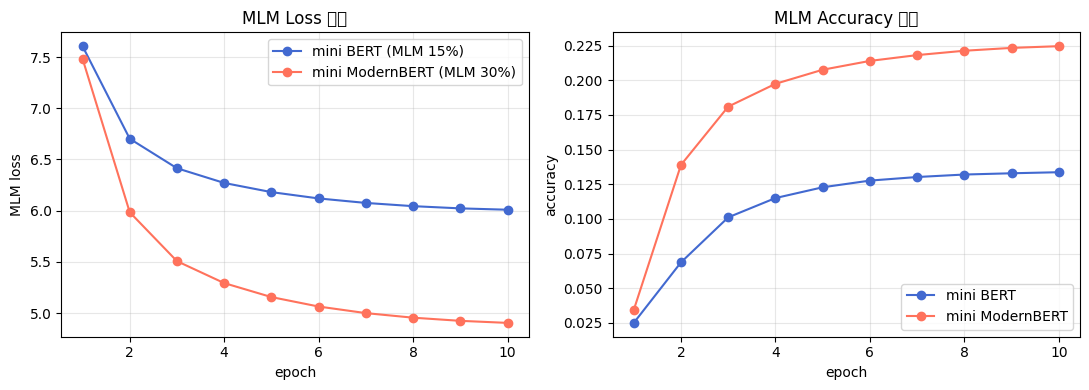

In [32]:
# --- 비교 시각화: mini BERT vs mini ModernBERT ---
if "history" not in dir():
    with open(f"{work_dir}/history.json") as f:
        history = json.load(f)

ex_b = [h["epoch"] for h in history]
ex_m = [h["epoch"] for h in modern_history]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(ex_b, [h["loss_lm"] for h in history],        color="#4269d0", marker="o", label="mini BERT (MLM 15%)")
ax.plot(ex_m, [h["loss_lm"] for h in modern_history], color="#ff725c", marker="o", label="mini ModernBERT (MLM 30%)")
ax.set_title("MLM Loss 비교")
ax.set_xlabel("epoch"); ax.set_ylabel("MLM loss")
ax.grid(alpha=0.3); ax.legend()

ax = axes[1]
ax.plot(ex_b, [h["acc_lm"] for h in history],        color="#4269d0", marker="o", label="mini BERT")
ax.plot(ex_m, [h["acc_lm"] for h in modern_history], color="#ff725c", marker="o", label="mini ModernBERT")
ax.set_title("MLM Accuracy 비교")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig(f"{work_dir}/modern_comparison.png", dpi=150)
plt.show()

In [33]:
def modern_fill_mask(model, vocab, text, topk=5):
    model.eval()
    pieces = ["[CLS]"]
    for word in text.split():
        if word == "[MASK]":
            pieces.append("[MASK]")
        else:
            pieces.extend(vocab.encode_as_pieces(word))
    pieces.append("[SEP]")
    ids = torch.tensor([[vocab.piece_to_id(p) for p in pieces]], dtype=torch.long, device=device)
    with torch.no_grad():
        logits_lm = model(ids)
    print("입력:", text)
    for pos, p in enumerate(pieces):
        if p == "[MASK]":
            top = logits_lm[0, pos].topk(topk)
            print(f"  [MASK] 위치 {pos} 예측 top{topk}:", [vocab.id_to_piece(int(i)) for i in top.indices])
    print()

modern_fill_mask(modern_model, vocab, "겨울이 되어서 날씨가 무척 [MASK] .")
modern_fill_mask(modern_model, vocab, "대한민국의 수도는 [MASK] 이다 .")

print("확장 실험 완료")
elapsed()

입력: 겨울이 되어서 날씨가 무척 [MASK] .
  [MASK] 위치 10 예측 top5: ['▁-', '이', '가', '을', '▁때']

입력: 대한민국의 수도는 [MASK] 이다 .
  [MASK] 위치 4 예측 top5: ['▁대한민국의', '▁가수', '▁배우', '▁미국의', '▁정치인']

확장 실험 완료
--- 누적 경과 시간: 31.6분 ---
